In [5]:
!pip install xgboost openpyxl -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

In [8]:
from google.colab import files

uploaded = files.upload()

Saving india_weather_rainfall_data.xlsx to india_weather_rainfall_data.xlsx


In [9]:
import pandas as pd

df = pd.read_excel("india_weather_rainfall_data.xlsx")

df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [10]:
df

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.0500,74.4000,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.0500,74.4000,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.0500,74.4000,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.0500,74.4000,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.0500,74.4000,25.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970334,2025-02-06,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,27.3,22.0,34.0,7.6,1011.4,5,17.7167,83.2333,0.0
970335,2025-02-07,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.7,23.0,30.0,7.7,1013.1,5,17.7167,83.2333,0.3
970336,2025-02-08,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.7,1013.0,5,17.7167,83.2333,0.0
970337,2025-02-09,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.5,1012.8,5,17.7167,83.2333,0.0


In [11]:
df.shape

(970339, 15)

In [12]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object')

In [13]:
print("Shape :", df.shape)

print("\nColumns:\n")
print(df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nFirst Five Rows:\n")
df.head()

Shape : (970339, 15)

Columns:

['date_of_record', 'month', 'season', 'station_name', 'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall']

Data Types:

date_of_record    datetime64[ns]
month                     object
season                    object
station_name              object
state                     object
district                  object
avg_temp                 float64
min_temp                 float64
max_temp                 float64
wind_speed               float64
air_pressure             float64
elevation                  int64
latitude                 float64
longitude                float64
rainfall                 float64
dtype: object

First Five Rows:



,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [14]:
# Randomly sample 300,000 rows
df = df.sample(
    300000,
    random_state=42
).sort_values(
    "date_of_record"
)

In [15]:
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Duplicates found: 0


In [16]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
air_pressure,94382
wind_speed,85036
rainfall,79649
max_temp,34297
min_temp,13660


In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date_of_record,300000,NaN,NaN,NaN,2021-03-26 03:08:47.616000,2015-01-01 00:00:00,2019-03-05 00:00:00,2021-11-06 00:00:00,2023-06-24 00:00:00,2025-02-10 00:00:00,NaN
month,300000,12,January,28854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,300000,4,Winter,103224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_name,300000,406,Srinagar,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,300000,32,MH,30579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,300000,314,Visakhapatnam,4131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_temp,300000.0,NaN,NaN,NaN,25.666284,-10.4,23.1,26.7,29.2,42.9,5.433915
min_temp,286340.0,NaN,NaN,NaN,20.645459,-18.5,17.1,22.4,25.0,35.6,6.004709
max_temp,265703.0,NaN,NaN,NaN,31.204545,-5.0,28.5,31.5,34.5,50.3,5.464566
wind_speed,214964.0,NaN,NaN,NaN,9.431045,0.0,6.1,8.4,11.6,66.6,4.978968


In [18]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [19]:
df.isna().sum()

,0
date_of_record,0
month,0
season,0
station_name,0
state,0
district,0
avg_temp,0
min_temp,13660
max_temp,34297
wind_speed,85036


In [20]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum().sum()

np.int64(0)

In [21]:
df.dropna(subset=['rainfall'], inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Data Cleaning Complete. Shape: {df.shape}")

Data Cleaning Complete. Shape: (300000, 15)


In [22]:
df.isna().sum()

,0
date_of_record,0
month,0
season,0
station_name,0
state,0
district,0
avg_temp,0
min_temp,0
max_temp,0
wind_speed,0


In [23]:
df_select = df.copy()

cols_to_drop = ['date_of_record', 'station_name']
df_select.drop(columns=[c for c in cols_to_drop if c in df_select.columns], inplace=True)

le_dict = {}
cat_cols = ['season', 'state', 'district', 'month']
for col in cat_cols:
    if col in df_select.columns:
        le = LabelEncoder()
        df_select[col] = le.fit_transform(df_select[col].astype(str))
        le_dict[col] = le


X = df_select.drop('rainfall', axis=1)
y = df_select['rainfall']

In [24]:
print("\nTop Features using T-Test (f_regression):")
selector_f = SelectKBest(score_func=f_regression, k=5)
X_new_f = selector_f.fit_transform(X, y)
selected_indices_f = selector_f.get_support(indices=True)
print("Top 5 Features (T-Test Logic):", X.columns[selected_indices_f].tolist())


Top Features using T-Test (f_regression):
Top 5 Features (T-Test Logic): ['season', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure']


In [25]:
# Extract date features

df["year"] = df["date_of_record"].dt.year
df["month_num"] = df["date_of_record"].dt.month
df["day"] = df["date_of_record"].dt.day
df["day_of_week"] = df["date_of_record"].dt.dayofweek
df["week"] = df["date_of_record"].dt.isocalendar().week.astype(int)

df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,year,month_num,day,day_of_week,week
137267,2015-01-01,January,Winter,Jodhpur,RJ,Jodhpur,17.2,11.2,22.7,8.4,1009.8,217,26.3000,73.0167,0.0,2015,1,1,3,1
796633,2015-01-01,January,Winter,Amini Divi,LD,Lakshadweep,27.4,22.4,31.6,8.4,1009.8,3,11.1167,72.7333,0.0,2015,1,1,3,1
765638,2015-01-01,January,Winter,Madras / Minambakkam,TN,Chennai,26.1,21.9,30.1,8.4,1009.8,10,13.0000,80.1833,0.0,2015,1,1,3,1
852787,2015-01-01,January,Winter,Karaikal,PY,Karaikal,26.8,24.7,29.9,8.4,1009.8,7,10.9167,79.8333,0.8,2015,1,1,3,1
337107,2015-01-01,January,Winter,Gandhinagar,GJ,Gandhinagar,19.9,22.4,24.3,8.4,1009.8,0,23.2333,72.7167,0.0,2015,1,1,3,1


In [26]:
df = df.sort_values("date_of_record")

df["rainfall_lag1"] = df["rainfall"].shift(1)
df["rainfall_lag2"] = df["rainfall"].shift(2)
df["rainfall_lag3"] = df["rainfall"].shift(3)

df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,...,longitude,rainfall,year,month_num,day,day_of_week,week,rainfall_lag1,rainfall_lag2,rainfall_lag3
137267,2015-01-01,January,Winter,Jodhpur,RJ,Jodhpur,17.2,11.2,22.7,8.4,...,73.0167,0.0,2015,1,1,3,1,NaN,NaN,NaN
394310,2015-01-01,January,Winter,Rajkot,GJ,Rajkot,17.4,22.4,22.6,8.4,...,70.7833,0.0,2015,1,1,3,1,0.0,NaN,NaN
197839,2015-01-01,January,Winter,Tezpur,AS,Sonitpur,18.8,22.4,26.5,8.4,...,92.7833,0.0,2015,1,1,3,1,0.0,0.0,NaN
593928,2015-01-01,January,Winter,Poona,MH,Pune,18.7,22.4,24.4,8.4,...,73.8500,0.0,2015,1,1,3,1,0.0,0.0,0.0
5182,2015-01-01,January,Winter,Srinagar,JK,Srinagar,0.2,-5.3,10.0,8.4,...,74.7833,0.0,2015,1,1,3,1,0.0,0.0,0.0


In [27]:
df["rainfall_roll3"] = df["rainfall"].rolling(3).mean()
df["rainfall_roll7"] = df["rainfall"].rolling(7).mean()

In [28]:
df.dropna(inplace=True)

print(df.shape)

(299994, 25)


In [29]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical = [
    "month",
    "season",
    "station_name",
    "state",
    "district"
]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,...,year,month_num,day,day_of_week,week,rainfall_lag1,rainfall_lag2,rainfall_lag3,rainfall_roll3,rainfall_roll7
57682,2015-01-01,4,3,136,26,93,10.8,22.4,18.6,8.4,...,2015,1,1,3,1,0.0,0.0,0.0,0.000000,0.000000
693628,2015-01-01,4,3,46,14,32,19.2,22.4,27.8,8.4,...,2015,1,1,3,1,0.0,0.0,0.0,0.000000,0.000000
734416,2015-01-01,4,3,89,14,59,23.7,19.7,31.4,8.4,...,2015,1,1,3,1,0.0,0.0,0.0,0.000000,0.000000
632100,2015-01-01,4,3,354,17,268,22.2,22.4,30.3,8.4,...,2015,1,1,3,1,0.0,0.0,0.0,1.366667,0.585714
154614,2015-01-01,4,3,218,30,170,15.7,13.0,20.4,8.4,...,2015,1,1,3,1,4.1,0.0,0.0,1.366667,0.585714


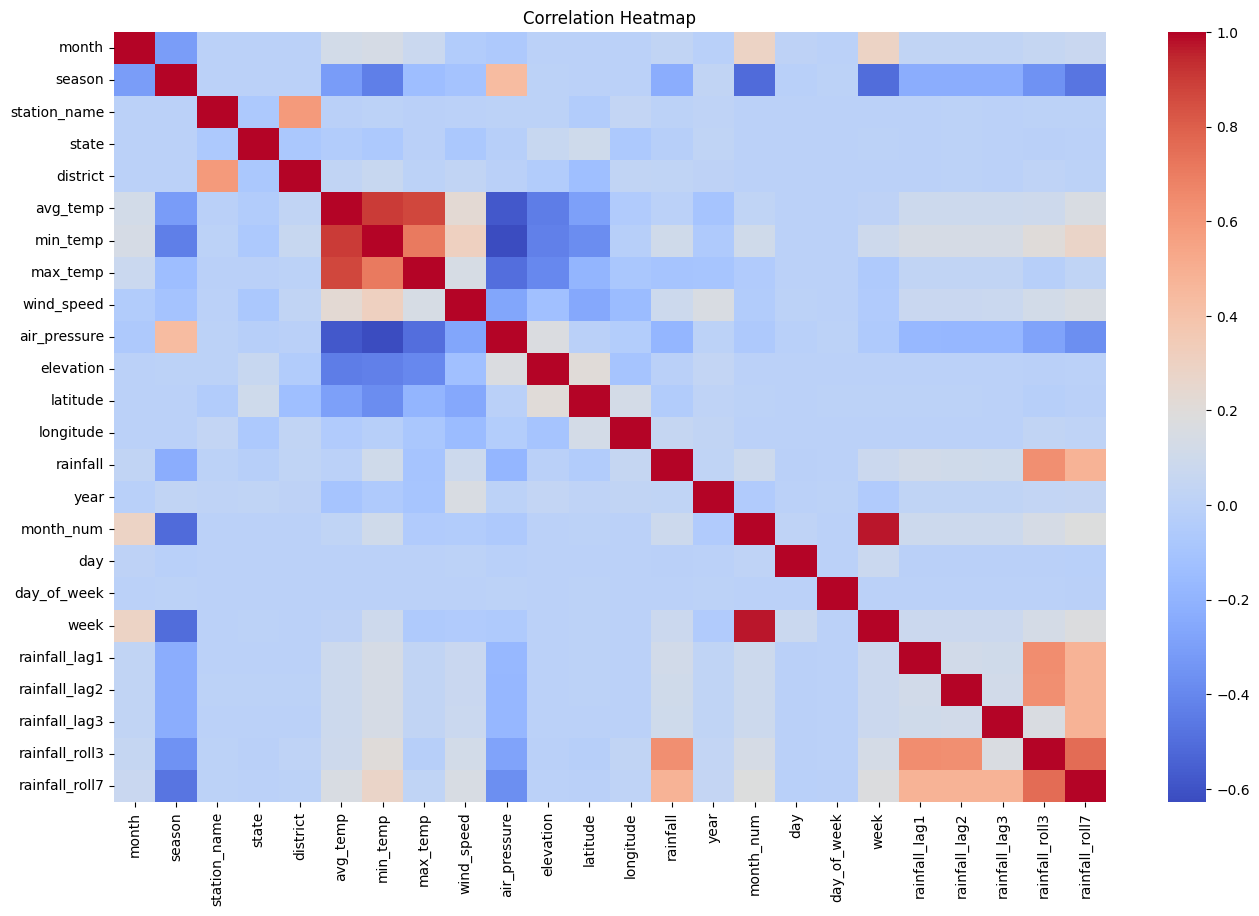

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [31]:
X = df.drop(
    columns=[
        "rainfall",
        "date_of_record"
    ]
)

y = df["rainfall"]

print(X.shape)

(299994, 23)


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
21,rainfall_roll3,0.536514
18,rainfall_lag1,0.285943
19,rainfall_lag2,0.163459
7,max_temp,0.003651
22,rainfall_roll7,0.002883
12,longitude,0.000989
5,avg_temp,0.000769
10,elevation,0.000629
9,air_pressure,0.000526
6,min_temp,0.000455


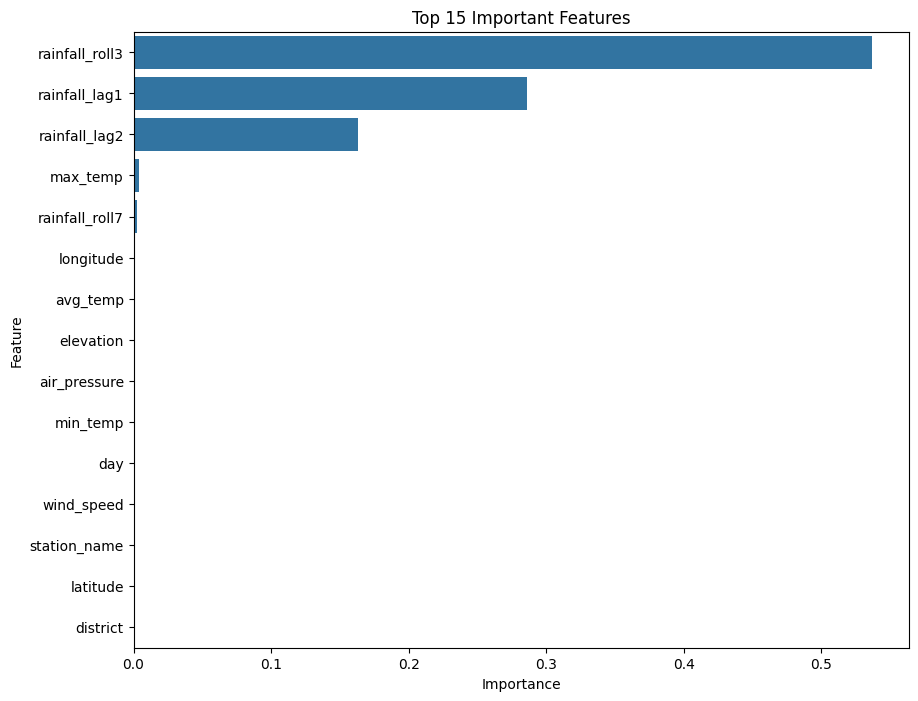

In [33]:
plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
split = int(len(df) * 0.8)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(239995, 23)
(59999, 23)


In [36]:
df = df.sort_values(["station_name", "date_of_record"])

df["rainfall_lag1"] = (
    df.groupby("station_name")["rainfall"].shift(1)
)

df["rainfall_lag2"] = (
    df.groupby("station_name")["rainfall"].shift(2)
)

df["rainfall_lag3"] = (
    df.groupby("station_name")["rainfall"].shift(3)
)

df["rainfall_roll3"] = (
    df.groupby("station_name")["rainfall"]
      .rolling(3)
      .mean()
      .reset_index(level=0, drop=True)
)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 1.3178699942766147e-13
RMSE: 1.650366487858301e-13
R²  : 1.0


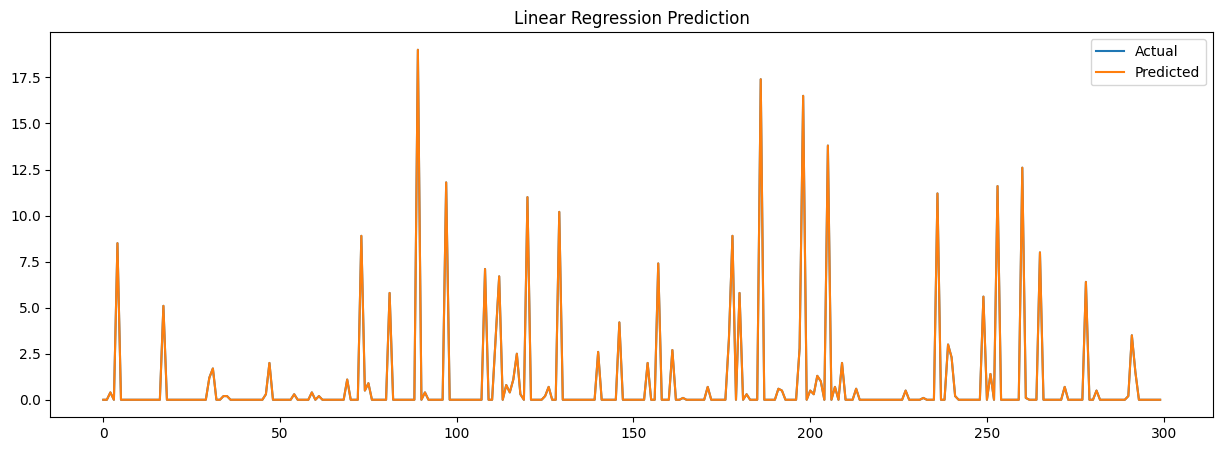

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_lr[:300], label="Predicted")

plt.legend()

plt.title("Linear Regression Prediction")

plt.show()

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.15339871497858315
RMSE: 0.7803278332724155
R²  : 0.9949076510482193


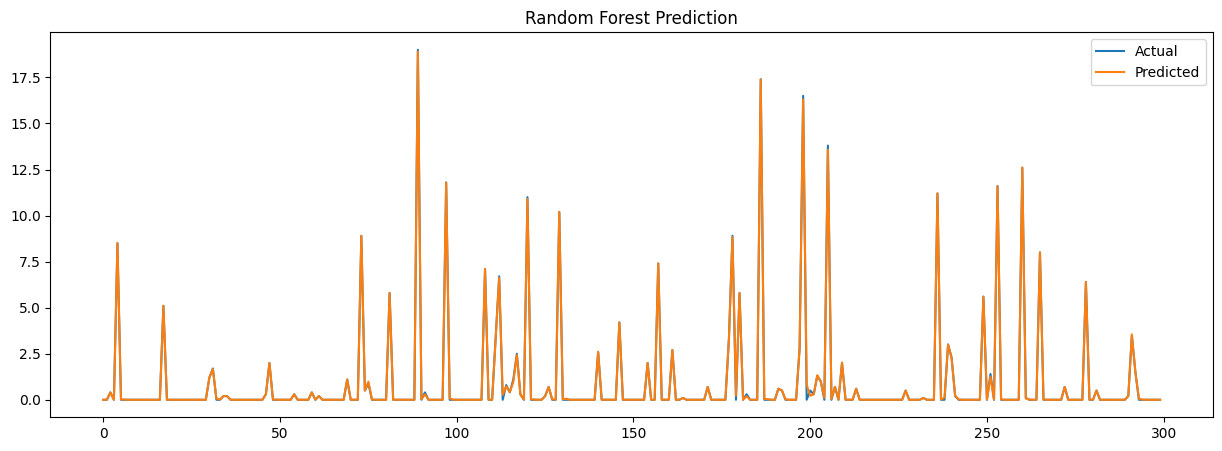

In [40]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_rf[:300], label="Predicted")

plt.legend()

plt.title("Random Forest Prediction")

plt.show()

In [41]:
!pip install xgboost

In [42]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
----------------
MAE : 0.36076083720220226
RMSE: 1.8133539633577678
R²  : 0.9725002255505716


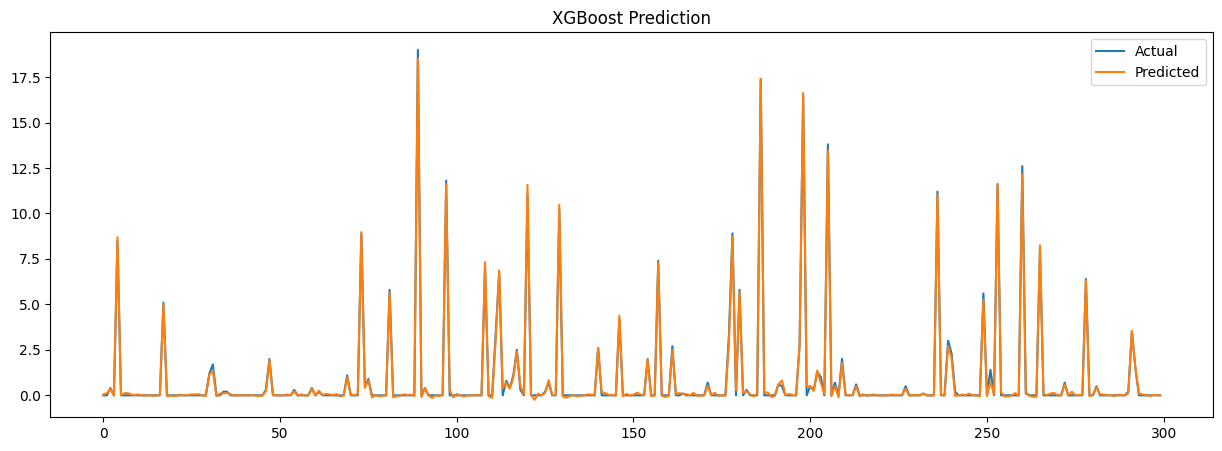

In [43]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_xgb[:300], label="Predicted")

plt.legend()

plt.title("XGBoost Prediction")

plt.show()

In [44]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost"],
    "MAE":[mae, mae_rf, mae_xgb],
    "RMSE":[rmse, rmse_rf, rmse_xgb],
    "R2 Score":[r2, r2_rf, r2_xgb]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.317870e-13,1.650366e-13,1.000000
1,Random Forest,1.533987e-01,7.803278e-01,0.994908
2,XGBoost,3.607608e-01,1.813354e+00,0.972500


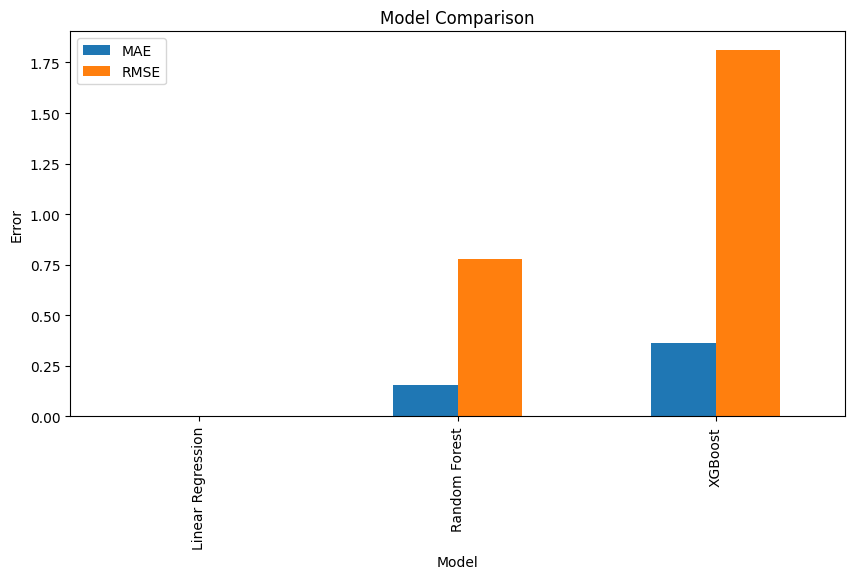

In [45]:
comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Error")

plt.show()

In [46]:
comparison.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.317870e-13,1.650366e-13,1.000000
1,Random Forest,1.533987e-01,7.803278e-01,0.994908
2,XGBoost,3.607608e-01,1.813354e+00,0.972500


In [47]:
# Create a fresh copy
dl_df = df.copy()

print(dl_df.shape)

(299994, 25)


In [48]:
dl_df = dl_df.sort_values(
    ["station_name", "date_of_record"]
).reset_index(drop=True)

dl_df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,...,year,month_num,day,day_of_week,week,rainfall_lag1,rainfall_lag2,rainfall_lag3,rainfall_roll3,rainfall_roll7
0,2015-01-02,4,3,0,29,311,23.1,18.6,30.3,8.4,...,2015,1,2,4,1,NaN,NaN,NaN,NaN,0.700000
1,2015-01-04,4,3,0,29,311,23.2,22.4,28.2,8.4,...,2015,1,4,6,1,0.0,NaN,NaN,NaN,4.242857
2,2015-01-06,4,3,0,29,311,16.9,22.4,25.3,8.4,...,2015,1,6,1,2,0.0,0.0,NaN,0.0,0.000000
3,2015-01-10,4,3,0,29,311,15.9,22.4,24.4,8.4,...,2015,1,10,5,2,0.0,0.0,0.0,0.0,0.000000
4,2015-01-16,4,3,0,29,311,21.4,22.4,28.6,8.4,...,2015,1,16,4,3,0.0,0.0,0.0,0.0,0.000000


In [49]:
lag_features = [1,2,3,7]

for lag in lag_features:

    dl_df[f"rainfall_lag_{lag}"] = (
        dl_df
        .groupby("station_name")["rainfall"]
        .shift(lag)
    )

In [50]:
rolling_windows = [3,7]

for window in rolling_windows:

    dl_df[f"rainfall_roll_{window}"] = (

        dl_df
        .groupby("station_name")["rainfall"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)

    )

In [51]:
print(dl_df.isna().sum().sort_values(ascending=False))

rainfall_lag_7     2842
rainfall_roll_7    2436
rainfall_lag3      1218
rainfall_lag_3     1218
rainfall_roll_3     812
rainfall_lag2       812
rainfall_roll3      812
rainfall_lag_2      812
rainfall_lag_1      406
rainfall_lag1       406
date_of_record        0
station_name          0
state                 0
month                 0
season                0
rainfall              0
longitude             0
latitude              0
elevation             0
air_pressure          0
wind_speed            0
max_temp              0
min_temp              0
avg_temp              0
district              0
week                  0
day_of_week           0
year                  0
month_num             0
day                   0
rainfall_roll7        0
dtype: int64


In [52]:
dl_df = dl_df.dropna().reset_index(drop=True)

print(dl_df.shape)

print(dl_df.isna().sum().sum())

(297152, 31)
0


In [53]:
from sklearn.preprocessing import LabelEncoder

categorical = [
    "month",
    "season",
    "station_name",
    "state",
    "district"
]

encoders = {}

for col in categorical:

    le = LabelEncoder()

    dl_df[col] = le.fit_transform(
        dl_df[col]
    )

    encoders[col] = le

In [54]:
X_dl = dl_df.drop(
    columns=[
        "rainfall",
        "date_of_record"
    ]
)

y_dl = dl_df["rainfall"]

print(X_dl.shape)

(297152, 29)


In [55]:
TIME_STEPS = 7

X_sequences = []
y_sequences = []

for station in dl_df["station_name"].unique():

    station_df = dl_df[dl_df["station_name"] == station]

    X_station = station_df.drop(
        columns=["rainfall", "date_of_record"]
    ).values

    y_station = station_df["rainfall"].values

    for i in range(TIME_STEPS, len(station_df)):
        X_sequences.append(
            X_station[i-TIME_STEPS:i]
        )

        y_sequences.append(
            y_station[i]
        )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print(X_sequences.shape)
print(y_sequences.shape)

(294310, 7, 29)
(294310,)


In [56]:
print("NaN :", np.isnan(X_sequences).sum())
print("Inf :", np.isinf(X_sequences).sum())

NaN : 0
Inf : 0


In [57]:
split = int(0.8 * len(X_sequences))

X_train = X_sequences[:split]
X_test = X_sequences[split:]

y_train = y_sequences[:split]
y_test = y_sequences[split:]

print(X_train.shape)
print(X_test.shape)

(235448, 7, 29)
(58862, 7, 29)


In [58]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

n_features = X_train.shape[2]

X_train_flat = X_train.reshape(-1, n_features)
X_test_flat = X_test.reshape(-1, n_features)

X_train_scaled = feature_scaler.fit_transform(X_train_flat)
X_test_scaled = feature_scaler.transform(X_test_flat)

X_train_scaled = X_train_scaled.reshape(
    X_train.shape
)

X_test_scaled = X_test_scaled.reshape(
    X_test.shape
)

In [59]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.reshape(-1,1)
)

y_test_scaled = target_scaler.transform(
    y_test.reshape(-1,1)
)

In [60]:
print("NaN X Train :", np.isnan(X_train_scaled).sum())
print("NaN X Test  :", np.isnan(X_test_scaled).sum())

print("NaN y Train :", np.isnan(y_train_scaled).sum())
print("NaN y Test  :", np.isnan(y_test_scaled).sum())

print("Inf X Train :", np.isinf(X_train_scaled).sum())
print("Inf X Test  :", np.isinf(X_test_scaled).sum())

NaN X Train : 0
NaN X Test  : 0
NaN y Train : 0
NaN y Test  : 0
Inf X Train : 0
Inf X Test  : 0


In [61]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same",
        input_shape=(
            X_train_scaled.shape[1],
            X_train_scaled.shape[2]
        )
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

model.add(
    Bidirectional(
        LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)

model.add(Dense(32, activation="relu"))

model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

In [62]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.Huber(),

    metrics=[
        "mae"
    ]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7, 64)          │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,609 (299.25 KB)

 Trainable params: 76,481 (298.75 KB)

 Non-trainable params: 128 (512.00 B)

In [63]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [64]:
history = model.fit(

    X_train_scaled,
    y_train_scaled,

    validation_split=0.2,

    epochs=20,

    batch_size=64,

    shuffle=False,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/20
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 4.0237e-04 - mae: 0.0132 - val_loss: 3.2009e-04 - val_mae: 0.0101 - learning_rate: 0.0010
Epoch 2/20
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 3.5737e-04 - mae: 0.0122 - val_loss: 3.2484e-04 - val_mae: 0.0093 - learning_rate: 0.0010
Epoch 3/20
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 3.4634e-04 - mae: 0.0119 - val_loss: 3.4901e-04 - val_mae: 0.0080 - learning_rate: 0.0010
Epoch 4/20
2940/2944 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8904e-04 - mae: 0.0108
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 3.3370e-04 - mae: 0.0116 - val_loss: 3.1673e-04 - val_mae: 0.0101 - learning_rate: 0.0010
Epoch 5/20
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - loss: 3.1269e-04 - mae: 0.0109 - val_loss: 3.1506e-04 - val_mae: 0.0098 - learning_rate: 5.0000e-04
Epoch 6/20
2944/2944 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 3.0110e-0

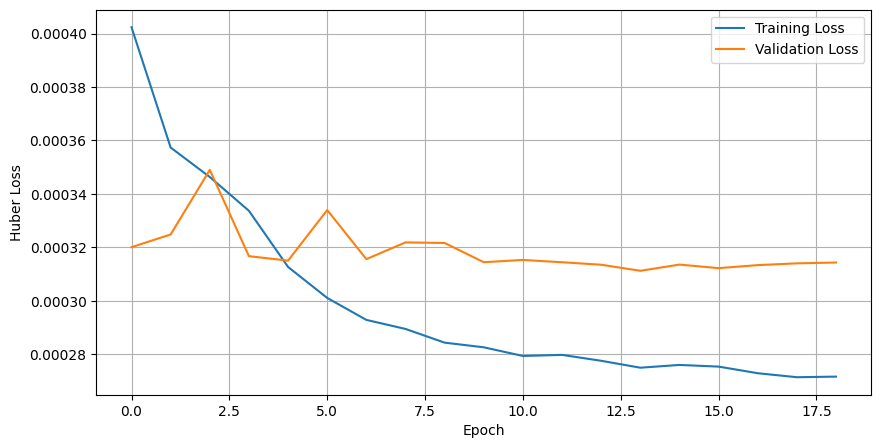

In [65]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Huber Loss")

plt.legend()

plt.grid(True)

plt.show()

In [66]:
pred_scaled = model.predict(X_test_scaled)

pred = target_scaler.inverse_transform(pred_scaled)

actual = target_scaler.inverse_transform(
    y_test_scaled
)

1840/1840 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [67]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_dl = mean_absolute_error(
    actual,
    pred
)

rmse_dl = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

r2_dl = r2_score(
    actual,
    pred
)

print("CNN + BiLSTM Results")
print("-------------------------")
print("MAE :", round(mae_dl,4))
print("RMSE:", round(rmse_dl,4))
print("R²  :", round(r2_dl,4))

CNN + BiLSTM Results
-------------------------
MAE : 4.5976
RMSE: 11.309
R²  : 0.1103


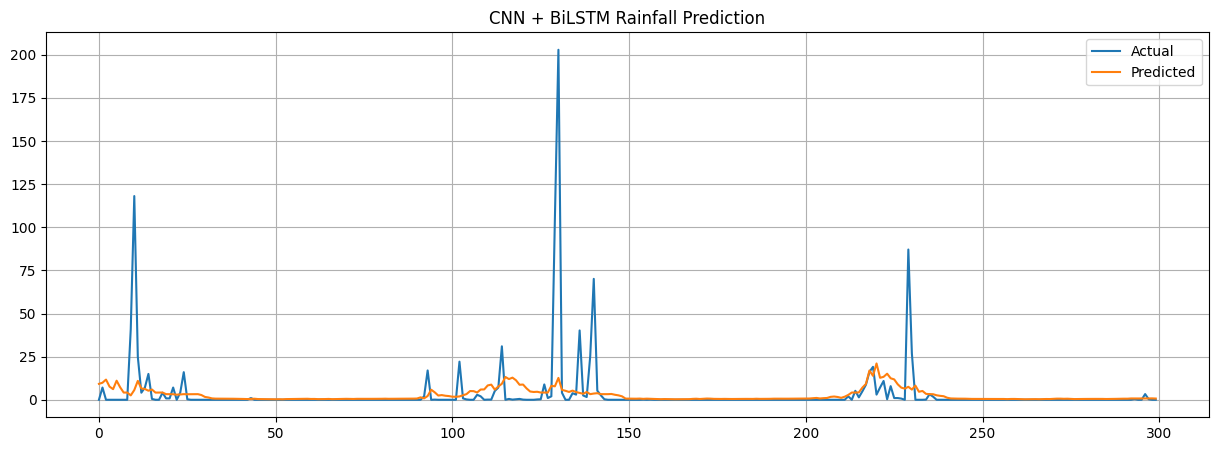

In [68]:
plt.figure(figsize=(15,5))

plt.plot(
    actual[:300],
    label="Actual"
)

plt.plot(
    pred[:300],
    label="Predicted"
)

plt.title("CNN + BiLSTM Rainfall Prediction")

plt.legend()

plt.grid(True)

plt.show()

In [69]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "CNN + BiLSTM"
    ],

    "MAE":[
        mae,
        mae_rf,
        mae_xgb,
        mae_dl
    ],

    "RMSE":[
        rmse,
        rmse_rf,
        rmse_xgb,
        rmse_dl
    ],

    "R²":[
        r2,
        r2_rf,
        r2_xgb,
        r2_dl
    ]

})

comparison.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
0,Linear Regression,1.317870e-13,1.650366e-13,1.000000
1,Random Forest,1.533987e-01,7.803278e-01,0.994908
2,XGBoost,3.607608e-01,1.813354e+00,0.972500
3,CNN + BiLSTM,4.597582e+00,1.130902e+01,0.110345


In [70]:
print("\nTop Features using Chi-Square:")

y_binned = pd.cut(y, bins=[-1, 0, 5, np.inf], labels=[0, 1, 2])

X_non_neg = MinMaxScaler().fit_transform(X)

selector_chi = SelectKBest(score_func=chi2, k=5)

if y_binned.isnull().sum() > 0:
    y_binned = y_binned.fillna(0)

X_new_chi = selector_chi.fit_transform(X_non_neg, y_binned)
selected_indices_chi = selector_chi.get_support(indices=True)
print("Top 5 Features (Chi-Square Logic):", X.columns[selected_indices_chi].tolist())


Top Features using Chi-Square:
Top 5 Features (Chi-Square Logic): ['season', 'year', 'month_num', 'rainfall_roll3', 'rainfall_roll7']


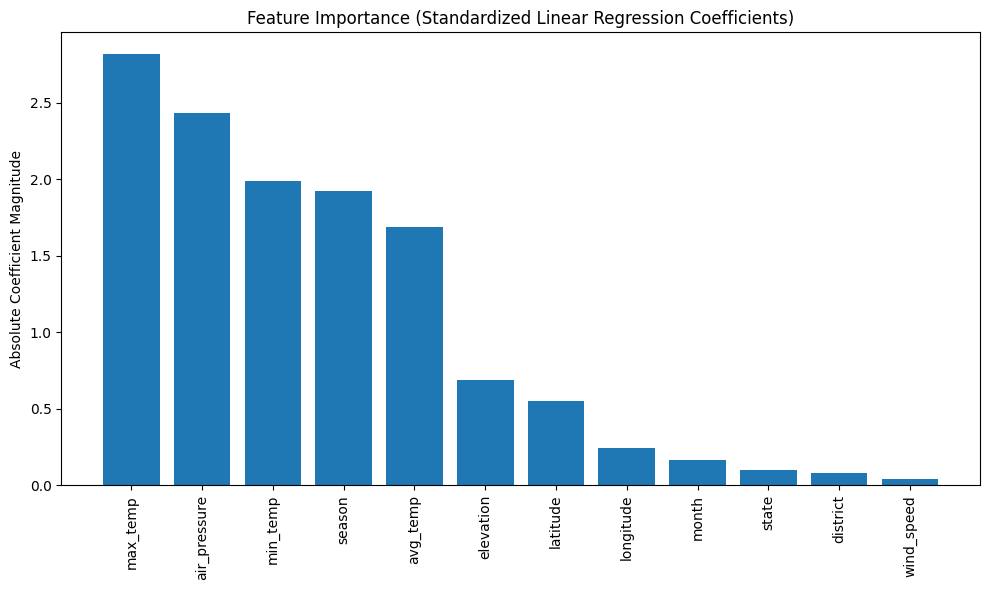

In [71]:
sample_df = df_select.sample(n=min(10000, len(df_select)), random_state=42)
X_sample = sample_df.drop('rainfall', axis=1)
y_sample = sample_df['rainfall']


scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)


model_lr = LinearRegression()
model_lr.fit(X_sample_scaled, y_sample)


importances = np.abs(model_lr.coef_)
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Standardized Linear Regression Coefficients)")
plt.bar(range(X_sample.shape[1]), importances[indices], align="center")


plt.xticks(range(X_sample.shape[1]), X_sample.columns[indices], rotation=90)
plt.ylabel("Absolute Coefficient Magnitude")
plt.tight_layout()
plt.show()

Total Features: 23
Performing PCA as features > 5...
Original Feature Count: 23
Reduced Feature Count (PCA): 17
Explained Variance Ratio: 0.9591


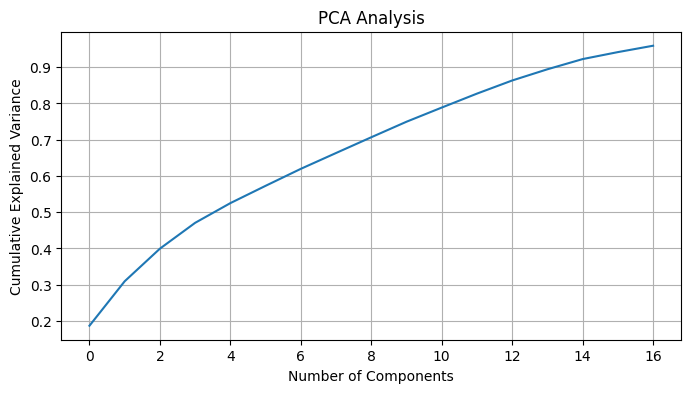

In [72]:
print(f"Total Features: {len(X.columns)}")

if len(X.columns) > 5:
    print("Performing PCA as features > 5...")


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=0.95)
    X_pca = pca.fit_transform(X_scaled)

    print(f"Original Feature Count: {X.shape[1]}")
    print(f"Reduced Feature Count (PCA): {X_pca.shape[1]}")
    print(f"Explained Variance Ratio: {np.sum(pca.explained_variance_ratio_):.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Analysis')
    plt.grid(True)
    plt.show()

Original Data Size: (300000, 13)
Super Optimized Data Size (85% retention): (256027, 13)
Max Rainfall in optimized data: 6.1

Regression Evaluation Metrics:
MAE: 0.6711
MSE: 1.2182
RMSE: 1.1037
R2 Score: 0.1585


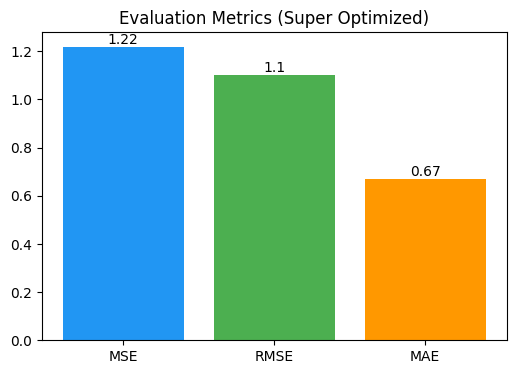

In [73]:
q_low = df_select['rainfall'].quantile(0.0)
q_high = df_select['rainfall'].quantile(0.85)
df_super_opt = df_select[(df_select['rainfall'] >= q_low) & (df_select['rainfall'] <= q_high)]

print(f"Original Data Size: {df_select.shape}")
print(f"Super Optimized Data Size (85% retention): {df_super_opt.shape}")
print(f"Max Rainfall in optimized data: {df_super_opt['rainfall'].max()}")


X_super = df_super_opt.drop('rainfall', axis=1)
y_super = df_super_opt['rainfall']


X_train, X_test, y_train, y_test = train_test_split(X_super, y_super, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRegression Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


plt.figure(figsize=(6, 4))
bars = plt.bar(['MSE', 'RMSE', 'MAE'], [mse, rmse, mae], color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Evaluation Metrics (Super Optimized)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom', ha='center')
plt.show()

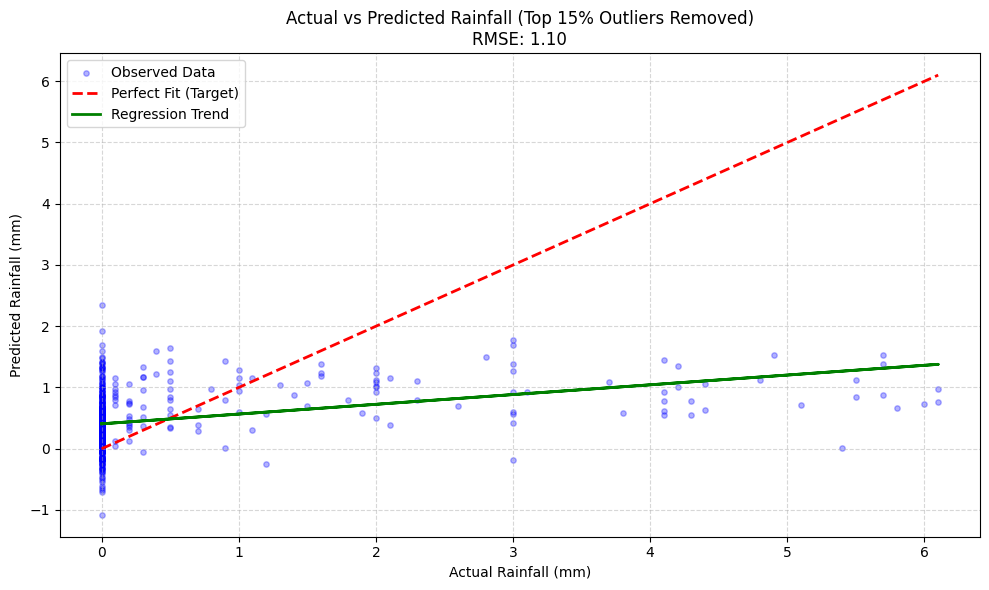

In [74]:
plt.figure(figsize=(10, 6))


plt.scatter(y_test[:500], y_pred[:500], color='blue', alpha=0.3, s=15, label='Observed Data')


limit_max = max(y_test.max(), y_pred.max())
plt.plot([0, limit_max], [0, limit_max], 'r--', linewidth=2, label='Perfect Fit (Target)')


m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b, color='green', linewidth=2, label='Regression Trend')


plt.title(f'Actual vs Predicted Rainfall (Top 15% Outliers Removed)\nRMSE: {rmse:.2f}', fontsize=12)
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

In [ ]:
def predict_rainfall(input_data):

    input_df = pd.DataFrame([input_data])

    try:
        prediction = lr_model.predict(input_df)
        return prediction[0]
    except Exception as e:
        return f"Error: {str(e)}"


print("--- Prediction Pipeline Test ---")
sample_input = X_test.iloc[0].to_dict()
print("Input Features:", sample_input)
predicted_val = predict_rainfall(sample_input)
print(f"\nPredicted Rainfall: {predicted_val:.2f} mm")
print(f"Actual Rainfall: {y_test.iloc[0]:.2f} mm")

In [78]:
import joblib

model.save("cnn_bilstm_model.keras")

joblib.dump(feature_scaler, "feature_scaler.pkl")

joblib.dump(target_scaler, "target_scaler.pkl")

joblib.dump(encoders, "label_encoders.pkl")

print("All models and preprocessors saved!")

All models and preprocessors saved!


In [76]:
cnn_bilstm_model.keras
feature_scaler.pkl
target_scaler.pkl
label_encoders.pkl
xgboost_model.pkl

NameError: name 'cnn_bilstm_model' is not defined

In [79]:
model.save("cnn_bilstm_model.keras")

joblib.dump(feature_scaler, "feature_scaler.pkl")

joblib.dump(target_scaler, "target_scaler.pkl")

joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [81]:
import joblib

joblib.dump(xgb, "xgboost_model.pkl")

['xgboost_model.pkl']

In [82]:
import os

print(os.listdir())

['.config', 'xgboost_model.pkl', 'target_scaler.pkl', 'cnn_bilstm_model.keras', 'india_weather_rainfall_data.xlsx', 'label_encoders.pkl', 'feature_scaler.pkl', 'sample_data']


In [84]:
from google.colab import files
files.download("xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
files.download("feature_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [86]:
files.download("target_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
files.download("cnn_bilstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
print(X.columns.tolist())

['month', 'season', 'station_name', 'state', 'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 'elevation', 'latitude', 'longitude', 'year', 'month_num', 'day', 'day_of_week', 'week', 'rainfall_lag1', 'rainfall_lag2', 'rainfall_lag3', 'rainfall_roll3', 'rainfall_roll7']


In [90]:
print(encoders)

{'month': LabelEncoder(), 'season': LabelEncoder(), 'station_name': LabelEncoder(), 'state': LabelEncoder(), 'district': LabelEncoder()}


In [91]:
print(type(encoders))

<class 'dict'>
